###1. Does trip distance significantly affect fare amount?
(Hint: Use Pearson correlation, covariance, and linear algebra interpretation.)

Saving Trip_Analysis.xlsx to Trip_Analysis (2).xlsx
DATASET PREVIEW
   Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
0              8   270.569350        Shared               2.5   
1             21   275.161032       Economy               2.5   
2             16   359.748971       Economy               2.0   
3             12   264.044264       Premium               1.5   
4              9   225.256916        Shared               2.0   

   Customer_Rating Ride_Time  
0                3  Non-Peak  
1                3  Non-Peak  
2                5  Non-Peak  
3                5  Non-Peak  
4                2  Non-Peak  

DATASET SHAPE
Rows: 200
Columns: 6

COLUMN NAMES
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Cleaned Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

IDENTIFIED COLUMNS
Distance Column: Trip_Distance
Fare Column: Fare_Amount

C

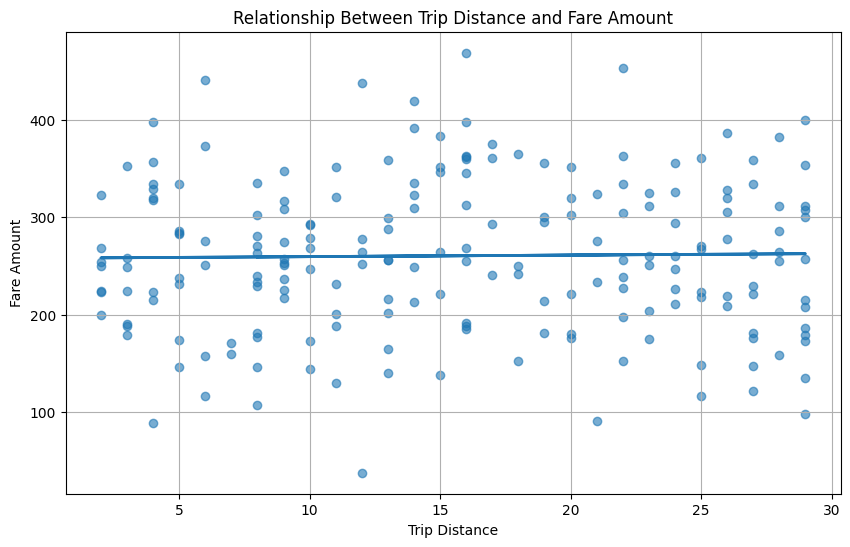


FINAL RESULT
Pearson Correlation: 0.016813110993310933
Covariance: 11.160172520076761
P-value: 0.8132001771984599
R-squared: 0.0002826807012733929
Regression Slope: 0.15690700713118205
Regression Intercept: 257.8583504129058

FINAL CONCLUSION:
Trip distance does not show a statistically significant relationship with fare amount at the 5% significance level.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("=" * 60)
print("DATASET PREVIEW")
print("=" * 60)
print(df.head())
print("\n" + "=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)
print(df.columns.tolist())

df.columns = df.columns.astype(str).str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())


distance_column = None
fare_column = None

for column in df.columns:

    column_name = column.lower().strip()

    if "distance" in column_name:
        distance_column = column

    if "fare" in column_name:
        fare_column = column


print("\n" + "=" * 60)
print("IDENTIFIED COLUMNS")
print("=" * 60)
print("Distance Column:", distance_column)
print("Fare Column:", fare_column)


if distance_column is None or fare_column is None:

    print("\nERROR: Distance or Fare column was not found.")

    print("\nAvailable columns are:")
    for column in df.columns:
        print("-", column)

    raise ValueError("\nPlease check the column names shown above.")


analysis_df = df[[distance_column, fare_column]].copy()

analysis_df.columns = ["Trip_Distance", "Fare_Amount"]

analysis_df["Trip_Distance"] = pd.to_numeric(analysis_df["Trip_Distance"],errors="coerce")

analysis_df["Fare_Amount"] = pd.to_numeric(analysis_df["Fare_Amount"],errors="coerce")

analysis_df = analysis_df.dropna()

print("\n" + "=" * 60)
print("CLEANED DATA")
print("=" * 60)
print(analysis_df.head())
print("\nNumber of valid observations:",len(analysis_df))
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
print(analysis_df.describe())


distance = analysis_df["Trip_Distance"].values
fare = analysis_df["Fare_Amount"].values

mean_distance = np.mean(distance)
mean_fare = np.mean(fare)

print("\n" + "=" * 60)
print("MEAN VALUES")
print("=" * 60)

print("Mean Trip Distance:", mean_distance)
print("Mean Fare Amount:", mean_fare)

covariance_matrix = np.cov(distance, fare)

covariance = covariance_matrix[0, 1]

print("\n" + "=" * 60)
print("COVARIANCE")
print("=" * 60)

print("Covariance Matrix:")
print(covariance_matrix)

print("\nCovariance between Trip Distance and Fare:",covariance)

correlation, p_value = pearsonr(distance, fare)

print("\n" + "=" * 60)
print("PEARSON CORRELATION")
print("=" * 60)
print("Correlation coefficient:", correlation)
print("P-value:", p_value)




print("\n" + "=" * 60)
print("CORRELATION INTERPRETATION")
print("=" * 60)

if correlation > 0:
    direction = "Positive"
elif correlation < 0:
    direction = "Negative"
else:
    direction = "No"

absolute_correlation = abs(correlation)

if absolute_correlation < 0.20:
    strength = "Very Weak"
elif absolute_correlation < 0.40:
    strength = "Weak"
elif absolute_correlation < 0.60:
    strength = "Moderate"
elif absolute_correlation < 0.80:
    strength = "Strong"
else:
    strength = "Very Strong"

print("Direction:", direction)
print("Strength:", strength)


r_squared = correlation ** 2

print("\n" + "=" * 60)
print("R-SQUARED")
print("=" * 60)

print("R-squared:", r_squared)
print("Percentage of fare variation explained by distance:",r_squared * 100, "%")
print("\n" + "=" * 60)
print("HYPOTHESIS TEST")
print("=" * 60)
print("H0: Trip distance has no significant relationship with fare.")
print("H1: Trip distance has a significant relationship with fare.")

alpha = 0.05

print("\nSignificance level:", alpha)
print("P-value:", p_value)


if p_value < alpha:

    print("\nDecision: Reject H0")

    print(
        "Conclusion: Trip distance has a statistically "
        "significant relationship with fare amount.")

else:

    print("\nDecision: Fail to reject H0")

    print(
        "Conclusion: There is not enough statistical evidence "
        "to say that trip distance significantly affects fare amount.")


distance_centered = distance - mean_distance
fare_centered = fare - mean_fare

dot_product = np.dot(distance_centered,fare_centered)

distance_norm = np.linalg.norm(distance_centered)

fare_norm = np.linalg.norm(fare_centered)
cosine_similarity = (dot_product /(distance_norm * fare_norm))

print("\n" + "=" * 60)
print("LINEAR ALGEBRA INTERPRETATION")
print("=" * 60)

print("Dot Product:", dot_product)

print("Distance Vector Norm:", distance_norm)

print("Fare Vector Norm:", fare_norm)

print("Cosine Similarity:", cosine_similarity)
slope, intercept = np.polyfit(distance,fare,1)

print("\n" + "=" * 60)
print("LINEAR REGRESSION")
print("=" * 60)

print("Slope:", slope)
print("Intercept:", intercept)

print("\nRegression Equation:")

print("Fare =",slope,"* Trip Distance +",intercept)
predicted_fare = (slope * distance + intercept)


plt.figure(figsize=(10, 6))

plt.scatter(distance,fare,alpha=0.6)

plt.plot(distance,predicted_fare,linewidth=2)

plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.title("Relationship Between Trip Distance and Fare Amount")

plt.grid(True)

plt.show()


print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Pearson Correlation:", correlation)

print("Covariance:", covariance)

print("P-value:", p_value)

print("R-squared:", r_squared)

print("Regression Slope:", slope)

print("Regression Intercept:", intercept)


if p_value < 0.05:

    print(
        "\nFINAL CONCLUSION:")

    print(
        "Trip distance has a statistically significant "
        "relationship with fare amount.")

    if correlation > 0:
        print(
            "The relationship is positive, meaning that "
            "fare generally increases as trip distance increases.")

else:

    print(
        "\nFINAL CONCLUSION:")

    print(
        "Trip distance does not show a statistically significant "
        "relationship with fare amount at the 5% significance level.")

###2. Are premium rides statistically more expensive than economy rides?
(Hint: Compare groups using t-test / ANOVA and summarize with descriptive statistics.)

Saving Trip_Analysis.xlsx to Trip_Analysis (4).xlsx
DATASET PREVIEW
   Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
0              8   270.569350        Shared               2.5   
1             21   275.161032       Economy               2.5   
2             16   359.748971       Economy               2.0   
3             12   264.044264       Premium               1.5   
4              9   225.256916        Shared               2.0   

   Customer_Rating Ride_Time  
0                3  Non-Peak  
1                3  Non-Peak  
2                5  Non-Peak  
3                5  Non-Peak  
4                2  Non-Peak  

DATASET SIZE
Number of rows    : 200
Number of columns : 6

ALL COLUMN NAMES
0 : Trip_Distance
1 : Fare_Amount
2 : Ride_Category
3 : Surge_Multiplier
4 : Customer_Rating
5 : Ride_Time

FARE COLUMN
Fare column identified as: Fare_Amount

POSSIBLE RIDE CATEGORY COLUMNS
- Ride_Category
- Ride_Time

RIDE CATEGORY COLUMN
Ride category column: Ride_Category


/tmp/ipykernel_830/2867359739.py:785: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


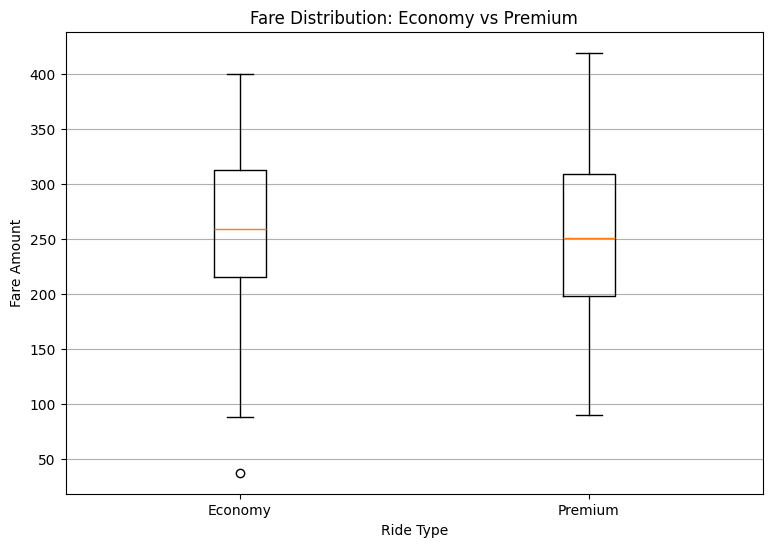

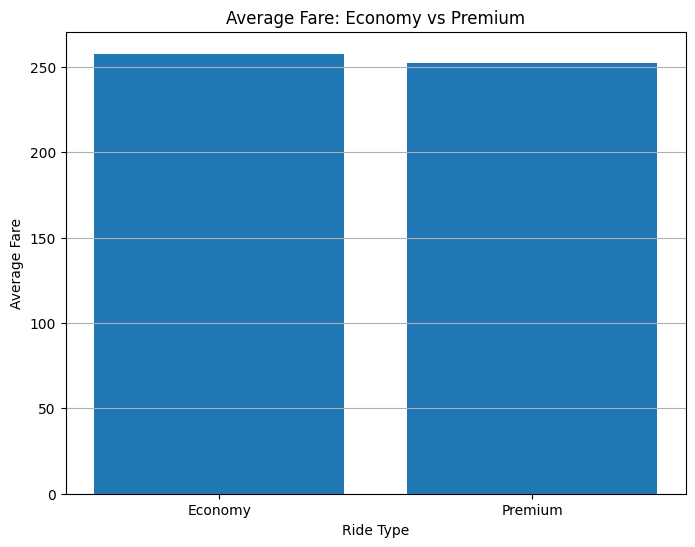


FINAL ANSWER
Average Premium Fare  : 252.46
Average Economy Fare  : 257.75
Difference in Mean    : -5.29
T-statistic           : -0.4060
One-tailed P-value    : 0.657273
ANOVA F-statistic     : 0.1660
ANOVA P-value         : 0.684345

CONCLUSION
Premium rides cannot be concluded to be statistically more expensive than economy rides at the 5% significance level.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
print("=" * 70)
print("DATASET PREVIEW")
print("=" * 70)

print(df.head())
print("\n" + "=" * 70)
print("DATASET SIZE")
print("=" * 70)

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])


print("\n" + "=" * 70)
print("ALL COLUMN NAMES")
print("=" * 70)

for i, column in enumerate(df.columns):
    print(i, ":", column)

df.columns = (
    df.columns
    .astype(str)
    .str.strip())

fare_column = None

for column in df.columns:

    name = column.lower().strip()

    if "fare" in name:

        fare_column = column
        break

if fare_column is None:

    print("\nFare column was not automatically identified.")

    print("\nAvailable columns:")

    for column in df.columns:
        print("-", column)

    raise ValueError(
        "Fare column not found. Check the column names above.")


print("\n" + "=" * 70)
print("FARE COLUMN")
print("=" * 70)

print("Fare column identified as:", fare_column)

possible_columns = []

for column in df.columns:

    name = column.lower().strip()

    if (
        "ride" in name
        or "service" in name
        or "category" in name
        or "type" in name
        or "class" in name):
        possible_columns.append(column)

print("\n" + "=" * 70)
print("POSSIBLE RIDE CATEGORY COLUMNS")
print("=" * 70)

if len(possible_columns) > 0:

    for column in possible_columns:
        print("-", column)

else:

    print("No obvious ride category column found.")
ride_column = None

for column in possible_columns:

    values = (
        df[column]
        .dropna()
        .astype(str)
        .str.lower())

    combined_values = " ".join(values.tolist())

    if (
        "premium" in combined_values
        or "economy" in combined_values):

        ride_column = column
        break

if ride_column is None and len(possible_columns) > 0:

    ride_column = possible_columns[0]

if ride_column is None:

    print("\nCould not automatically identify ride category.")

    print("\nAll columns and their data types:")

    print(df.dtypes)

    raise ValueError(
        "Ride category column could not be identified.")


print("\n" + "=" * 70)
print("RIDE CATEGORY COLUMN")
print("=" * 70)
print("Ride category column:", ride_column)
print("\n" + "=" * 70)
print("ACTUAL RIDE CATEGORIES IN YOUR DATASET")
print("=" * 70)

unique_categories = (
    df[ride_column]
    .dropna()
    .astype(str)
    .str.strip()
    .unique())

for category in unique_categories:

    print("-", category)


print("\n" + "=" * 70)
print("RIDE CATEGORY COUNTS")
print("=" * 70)

print(
    df[ride_column]
    .value_counts(dropna=False))
analysis_df = df[[ride_column, fare_column]].copy()
analysis_df.columns = ["Ride_Type","Fare_Amount"]

analysis_df["Ride_Type"] = (
    analysis_df["Ride_Type"]
    .astype(str)
    .str.strip())

analysis_df["Fare_Amount"] = (
    analysis_df["Fare_Amount"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip())
analysis_df["Fare_Amount"] = pd.to_numeric(analysis_df["Fare_Amount"],errors="coerce")
analysis_df = analysis_df.dropna(
    subset=[
        "Ride_Type",
        "Fare_Amount"])


analysis_df = analysis_df[analysis_df["Ride_Type"].str.lower() != "nan"]
print("\n" + "=" * 70)
print("CLEANED DATA")
print("=" * 70)
print(analysis_df.head())
print("\nNumber of valid observations:",len(analysis_df))

premium_df = analysis_df[
    analysis_df["Ride_Type"]
    .str.lower()
    .str.contains("premium",na=False)]

economy_df = analysis_df[analysis_df["Ride_Type"]
    .str.lower()
    .str.contains("economy",na=False)]

premium_fare = (premium_df["Fare_Amount"].dropna())
economy_fare = (economy_df["Fare_Amount"].dropna())

print("\n" + "=" * 70)
print("PREMIUM AND ECONOMY GROUPS")
print("=" * 70)
print("Number of Premium rides:",len(premium_fare))
print("Number of Economy rides:",len(economy_fare))

if len(premium_fare) == 0 or len(economy_fare) == 0:

    print("\n" + "=" * 70)
    print("PREMIUM / ECONOMY NOT FOUND")
    print("=" * 70)

    print(
        "\nYour dataset does not use the exact words "
        "'Premium' and 'Economy'.")

    print(
        "\nThe actual categories in your dataset are:")

    for category in unique_categories:

        print("-", category)

    print(
        "\nPlease use the actual category names from the "
        "list above for the two groups.")

else:
    print("\n" + "=" * 70)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 70)
    print("\nPREMIUM RIDES")
    print("-" * 50)
    print(premium_fare.describe())
    print("\nECONOMY RIDES")
    print("-" * 50)
    print(economy_fare.describe())



    premium_mean = premium_fare.mean()

    economy_mean = economy_fare.mean()


    print("\n" + "=" * 70)
    print("AVERAGE FARE")
    print("=" * 70)
    print("Average Premium Fare:",premium_mean)
    print("Average Economy Fare:",economy_mean)



    premium_median = premium_fare.median()
    economy_median = economy_fare.median()
    print("\n" + "=" * 70)
    print("MEDIAN FARE")
    print("=" * 70)
    print("Premium Median:",premium_median)
    print("Economy Median:",economy_median)


    premium_std = premium_fare.std()
    economy_std = economy_fare.std()
    print("\n" + "=" * 70)
    print("STANDARD DEVIATION")
    print("=" * 70)
    print("Premium Standard Deviation:",premium_std)
    print("Economy Standard Deviation:",economy_std)

    mean_difference = (premium_mean - economy_mean)
    print("\n" + "=" * 70)
    print("DIFFERENCE IN AVERAGE FARE")
    print("=" * 70)
    print("Premium Mean - Economy Mean =", mean_difference)


    t_statistic, two_tailed_p = ttest_ind(premium_fare,economy_fare,equal_var=False)
    print("\n" + "=" * 70)
    print("INDEPENDENT SAMPLES T-TEST")
    print("=" * 70)
    print("T-statistic:", t_statistic)
    print("Two-tailed P-value:",two_tailed_p)



    if t_statistic > 0:

        one_tailed_p = (two_tailed_p / 2)

    else:
        one_tailed_p = ( 1 - (two_tailed_p / 2))
    print("\nOne-tailed P-value:",one_tailed_p)


    alpha = 0.05
    print("\n" + "=" * 70)
    print("HYPOTHESIS TEST")
    print("=" * 70)

    print(
        "H0: Premium rides are not more expensive "
        "than economy rides.")

    print(
        "H1: Premium rides are more expensive "
        "than economy rides.")

    print("\nSignificance level:",alpha)

    print("One-tailed P-value:",one_tailed_p)
    if (
        one_tailed_p < alpha
        and premium_mean > economy_mean):

        print( "\nDecision: REJECT H0")
        print(
            "There is statistically significant evidence "
            "that premium rides are more expensive than "
            "economy rides.")
    else:
        print(
            "\nDecision: FAIL TO REJECT H0")

        print(
            "There is not enough statistical evidence "
            "to conclude that premium rides are more "
            "expensive than economy rides.")


    f_statistic, anova_p = f_oneway(premium_fare,economy_fare)
    print("\n" + "=" * 70)
    print("ONE-WAY ANOVA")
    print("=" * 70)
    print("F-statistic:",f_statistic)

    print("ANOVA P-value:",anova_p)
    if anova_p < alpha:

        print("\nANOVA Result:")
        print(
            "There is a statistically significant "
            "difference between the average fares "
            "of Premium and Economy rides.")

    else:
        print("\nANOVA Result:")
        print(
            "There is no statistically significant "
            "difference between the average fares.")

    summary_table = pd.DataFrame({"Statistic": ["Count","Mean","Median","Standard Deviation", "Minimum","Maximum"],
        "Premium": [len(premium_fare),premium_mean,premium_median,premium_std,premium_fare.min(),premium_fare.max()],
        "Economy": [len(economy_fare),economy_mean,economy_median,economy_std,economy_fare.min(),economy_fare.max()] })

    print("\n" + "=" * 70)
    print("PREMIUM VS ECONOMY SUMMARY")
    print("=" * 70)
    print(summary_table.to_string(index=False))

    plt.figure(figsize=(9, 6))
    plt.boxplot([economy_fare,premium_fare], labels=["Economy","Premium"])
    plt.xlabel("Ride Type")
    plt.ylabel("Fare Amount")
    plt.title("Fare Distribution: Economy vs Premium")
    plt.grid(axis="y")
    plt.show()
    plt.figure(figsize=(8, 6))
    plt.bar(["Economy","Premium"],[economy_mean,premium_mean])
    plt.xlabel("Ride Type")
    plt.ylabel("Average Fare")
    plt.title("Average Fare: Economy vs Premium")
    plt.grid(axis="y")
    plt.show()




    print("\n" + "=" * 70)
    print("FINAL ANSWER")
    print("=" * 70)
    print(f"Average Premium Fare  : {premium_mean:.2f}")
    print(f"Average Economy Fare  : {economy_mean:.2f}")
    print(f"Difference in Mean    : {mean_difference:.2f}")
    print(f"T-statistic           : {t_statistic:.4f}")
    print(f"One-tailed P-value    : {one_tailed_p:.6f}")
    print(f"ANOVA F-statistic     : {f_statistic:.4f}")
    print(f"ANOVA P-value         : {anova_p:.6f}")



    print("\n" + "=" * 70)
    print("CONCLUSION")
    print("=" * 70)
    if (
        one_tailed_p < 0.05
        and premium_mean > economy_mean):

        print(
            "Premium rides are statistically more expensive "
            "than economy rides at the 5% significance level.")

    else:

        print(
            "Premium rides cannot be concluded to be "
            "statistically more expensive than economy rides "
            "at the 5% significance level.")

####3. Is there a relationship between surge pricing and customer ratings?
(Hint: Use Spearman correlation and test significance statistically.)

Saving Trip_Analysis.xlsx to Trip_Analysis (5).xlsx
DATASET PREVIEW
   Trip_Distance  Fare_Amount Ride_Category  Surge_Multiplier  \
0              8   270.569350        Shared               2.5   
1             21   275.161032       Economy               2.5   
2             16   359.748971       Economy               2.0   
3             12   264.044264       Premium               1.5   
4              9   225.256916        Shared               2.0   

   Customer_Rating Ride_Time  
0                3  Non-Peak  
1                3  Non-Peak  
2                5  Non-Peak  
3                5  Non-Peak  
4                2  Non-Peak  

DATASET SIZE
Rows    : 200
Columns : 6

COLUMN NAMES
0 : Trip_Distance
1 : Fare_Amount
2 : Ride_Category
3 : Surge_Multiplier
4 : Customer_Rating
5 : Ride_Time

IDENTIFIED COLUMNS
Surge Pricing Column : Surge_Multiplier
Customer Rating Column: Customer_Rating

CLEANED DATA
   Surge_Pricing  Customer_Rating
0            2.5                3
1           

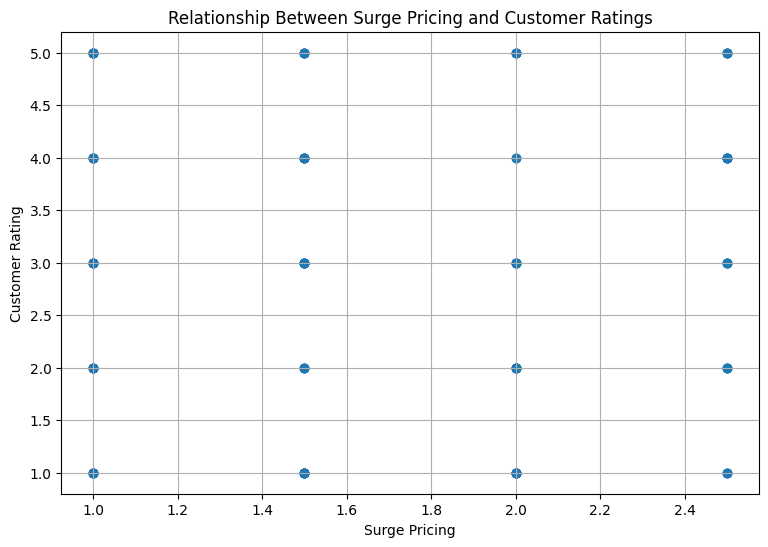


FINAL RESULTS
Spearman Correlation = -0.0471
P-value = 0.507870
Correlation Direction = Negative
Correlation Strength = Very Weak

FINAL CONCLUSION
There is no statistically significant relationship between surge pricing and customer ratings at the 5% significance level.

PRACTICAL INTERPRETATION
The analysis does not provide sufficient evidence that surge pricing is associated with customer ratings.

Note: Correlation shows association, not causation.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)
print("=" * 70)
print("DATASET PREVIEW")
print("=" * 70)
print(df.head())
print("\n" + "=" * 70)
print("DATASET SIZE")
print("=" * 70)
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])
print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)
for i, column in enumerate(df.columns):
    print(i, ":", column)


df.columns = (
    df.columns
    .astype(str)
    .str.strip())
surge_column = None

for column in df.columns:
    name = column.lower().strip()

    if (
        "surge" in name
        or "multiplier" in name
        or "surge pricing" in name):

        surge_column = column
        break


rating_column = None

for column in df.columns:

    name = column.lower().strip()

    if (
        "rating" in name
        or "customer rating" in name
        or "review" in name
        or "score" in name):
        rating_column = column
        break

print("\n" + "=" * 70)
print("IDENTIFIED COLUMNS")
print("=" * 70)

print("Surge Pricing Column :", surge_column)
print("Customer Rating Column:", rating_column)


if surge_column is None or rating_column is None:

    print("\nERROR: Required columns could not be identified.")

    print("\nAvailable columns in your dataset:")

    for column in df.columns:
        print("-", column)

    raise ValueError(
        "Surge pricing or customer rating column was not found. "
        "Check the column names printed above.")
analysis_df = df[[surge_column, rating_column]].copy()
analysis_df.columns = [ "Surge_Pricing","Customer_Rating"]




analysis_df["Surge_Pricing"] = (
    analysis_df["Surge_Pricing"]
    .astype(str)
    .str.replace("x", "", case=False, regex=False)
    .str.replace(",", "", regex=False)
    .str.strip())

analysis_df["Customer_Rating"] = (
    analysis_df["Customer_Rating"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip())

analysis_df["Surge_Pricing"] = pd.to_numeric(analysis_df["Surge_Pricing"],errors="coerce")
analysis_df["Customer_Rating"] = pd.to_numeric(analysis_df["Customer_Rating"],errors="coerce")
analysis_df = analysis_df.dropna(subset=["Surge_Pricing","Customer_Rating"])




print("\n" + "=" * 70)
print("CLEANED DATA")
print("=" * 70)
print(analysis_df.head(10))
print("\nNumber of valid observations:",len(analysis_df))


print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

print(analysis_df.describe())


mean_surge = analysis_df["Surge_Pricing"].mean()
mean_rating = analysis_df["Customer_Rating"].mean()
print("\n" + "=" * 70)
print("MEAN VALUES")
print("=" * 70)
print("Average Surge Pricing:",mean_surge)
print("Average Customer Rating:",mean_rating)


spearman_correlation, p_value = spearmanr(analysis_df["Surge_Pricing"],analysis_df["Customer_Rating"])
print("\n" + "=" * 70)
print("SPEARMAN CORRELATION")
print("=" * 70)
print("Spearman Correlation Coefficient:",spearman_correlation)
print("P-value:",p_value)


print("\n" + "=" * 70)
print("CORRELATION DIRECTION")
print("=" * 70)

if spearman_correlation > 0:direction = "Positive"

elif spearman_correlation < 0:direction = "Negative"

else:
    direction = "No relationship"
print("Direction:",direction)



absolute_correlation = abs(spearman_correlation)
if absolute_correlation < 0.20:

    strength = "Very Weak"

elif absolute_correlation < 0.40:

    strength = "Weak"

elif absolute_correlation < 0.60:

    strength = "Moderate"

elif absolute_correlation < 0.80:

    strength = "Strong"

else:

    strength = "Very Strong"
print("Strength:",strength)


alpha = 0.05
print("\n" + "=" * 70)
print("HYPOTHESIS TEST")
print("=" * 70)

print(
    "H0: There is no significant relationship between "
    "surge pricing and customer ratings.")

print(
    "H1: There is a significant relationship between "
    "surge pricing and customer ratings.")

print("\nSignificance Level:",alpha)

print("P-value:",p_value)



if p_value < alpha:

    print("\nDecision: REJECT H0")

    print(
        "There is statistically significant evidence "
        "of a relationship between surge pricing and "
        "customer ratings.")

else:

    print("\nDecision: FAIL TO REJECT H0")

    print(
        "There is not enough statistical evidence "
        "to conclude that surge pricing and customer "
        "ratings are significantly related.")


analysis_df["Surge_Rank"] = (analysis_df["Surge_Pricing"].rank())
analysis_df["Rating_Rank"] = (analysis_df["Customer_Rating"].rank())
print("\n" + "=" * 70)
print("RANKED DATA")
print("=" * 70)
print(analysis_df.head(10))



plt.figure(
    figsize=(9, 6))

plt.scatter(
    analysis_df["Surge_Pricing"],
    analysis_df["Customer_Rating"],
    alpha=0.6)

plt.xlabel("Surge Pricing")
plt.ylabel("Customer Rating")
plt.title("Relationship Between Surge Pricing and Customer Ratings")
plt.grid(True)
plt.show()



print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)
print(f"Spearman Correlation = {spearman_correlation:.4f}")
print(f"P-value = {p_value:.6f}")
print(f"Correlation Direction = {direction}")
print(f"Correlation Strength = {strength}")


print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

if p_value < 0.05:

    if spearman_correlation > 0:

        print(
            "There is a statistically significant positive "
            "relationship between surge pricing and customer "
            "ratings.")

    elif spearman_correlation < 0:

        print(
            "There is a statistically significant negative "
            "relationship between surge pricing and customer "
            "ratings.")

    else:
        print(
            "The statistical test is significant, but the "
            "correlation coefficient is approximately zero.")

else:
    print(
        "There is no statistically significant relationship "
        "between surge pricing and customer ratings at the "
        "5% significance level.")


print("\n" + "=" * 70)
print("PRACTICAL INTERPRETATION")
print("=" * 70)

if p_value < 0.05:

    print(
        "The analysis suggests that changes in surge pricing "
        "are associated with changes in customer ratings.")

else:

    print(
        "The analysis does not provide sufficient evidence "
        "that surge pricing is associated with customer ratings.")

print("\nNote: Correlation shows association, not causation.")


###4. Do peak-hour rides differ in revenue compared to non-peak rides?
(Hint: Apply z-test / t-test.)

Saving Trip_Analysis.xlsx to Trip_Analysis (6).xlsx
First 5 rows:


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak



Dataset Shape:
(200, 6)

Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Cleaned Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Revenue Column Identified:
Fare_Amount

Possible Peak/Time Columns:
['Ride_Time']

Peak/Time Column Selected:
Ride_Time

Unique values in Peak/Time column:
['Non-Peak' 'Peak']

Cleaned Peak Status Values:
Peak_Status
peak        103
non-peak     97
Name: count, dtype: int64

Cleaned Data:


,Peak_Status,Revenue
0,non-peak,270.569350
1,non-peak,275.161032
2,non-peak,359.748971
3,non-peak,264.044264
4,non-peak,225.256916



Number of Peak-Hour Rides:
103

Number of Non-Peak Rides:
97

DESCRIPTIVE STATISTICS

Peak-Hour Revenue:
count    103.000000
mean     257.074667
std       74.399868
min       98.209841
25%      205.625122
50%      254.871729
75%      318.772617
max      453.133017
Name: Revenue, dtype: float64

Non-Peak Revenue:
count     97.000000
mean     263.750356
std       83.285733
min       37.585916
25%      213.803021
50%      263.986641
75%      320.293884
max      468.753773
Name: Revenue, dtype: float64

Average Peak-Hour Revenue:
257.07

Average Non-Peak Revenue:
263.75

Median Peak-Hour Revenue:
254.87

Median Non-Peak Revenue:
263.99

Difference in Average Revenue:
-6.68

INDEPENDENT T-TEST

T-Statistic:
-0.5965

P-Value:
0.551548

Significance Level (α):
0.05

Null Hypothesis (H0):
There is no significant difference in revenue between peak-hour and non-peak rides.

Alternative Hypothesis (H1):
There is a significant difference in revenue between peak-hour and non-peak rides.

Decision:

,Group,Number of Rides,Mean Revenue,Median Revenue,Standard Deviation
0,Peak-Hour,103,257.074667,254.871729,74.399868
1,Non-Peak,97,263.750356,263.986641,83.285733


/tmp/ipykernel_830/79302035.py:443: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


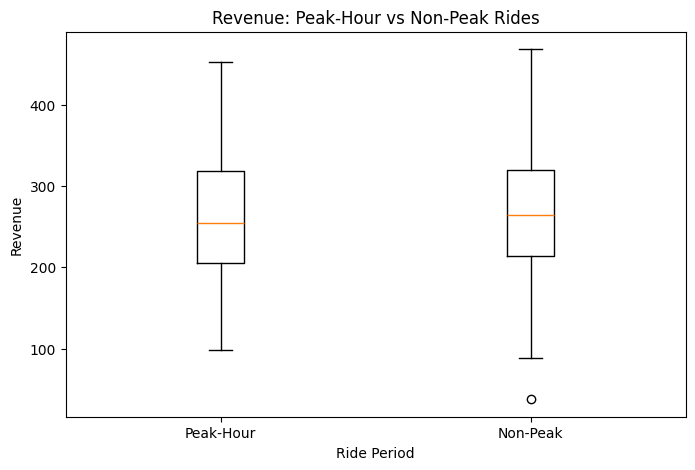

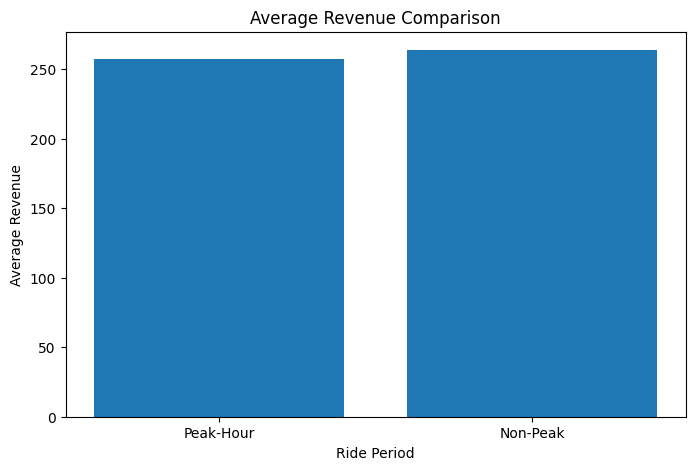


FINAL ANSWER - QUESTION 4
Peak-hour average revenue: 257.07
Non-peak average revenue: 263.75
T-statistic: -0.5965
P-value: 0.551548

Result: Peak-hour and non-peak rides do NOT have a statistically significant difference in revenue.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())

revenue_candidates = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["revenue", "fare", "amount", "earnings"])]

if len(revenue_candidates) == 0:
    print("\nRevenue column was not automatically identified.")
    print("Available columns:")
    print(df.columns.tolist())

    raise ValueError("Please check the column name containing revenue/fare.")
revenue_col = revenue_candidates[0]
print("\nRevenue Column Identified:")
print(revenue_col)


time_candidates = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["peak","hour","time","period","booking time","trip time"])]

print("\nPossible Peak/Time Columns:")
print(time_candidates)

if len(time_candidates) == 0:
    print("\nNo peak/time column was automatically identified.")
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError("Please check which column identifies peak and non-peak rides.")
peak_col = time_candidates[0]

print("\nPeak/Time Column Selected:")
print(peak_col)

print("\nUnique values in Peak/Time column:")
print(df[peak_col].unique())

analysis_df = df[[peak_col, revenue_col]].copy()

analysis_df.columns = ["Peak_Status", "Revenue"]


analysis_df["Revenue"] = (
    analysis_df["Revenue"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.strip())

analysis_df["Revenue"] = pd.to_numeric(
    analysis_df["Revenue"],
    errors="coerce")


analysis_df["Peak_Status"] = (
    analysis_df["Peak_Status"]
    .astype(str)
    .str.strip()
    .str.lower())

print("\nCleaned Peak Status Values:")
print(analysis_df["Peak_Status"].value_counts())

print("\nCleaned Data:")
display(analysis_df.head())




peak_keywords = ["peak","yes","true","1","high"]

non_peak_keywords = ["non-peak", "non peak","off-peak","off peak", "no", "false","0","low"]


def is_peak(value):
    value = str(value).lower().strip()
    return any(keyword == value for keyword in peak_keywords)

def is_non_peak(value):
    value = str(value).lower().strip()
    return any(keyword == value for keyword in non_peak_keywords)

peak_data = analysis_df[analysis_df["Peak_Status"].apply(is_peak)]["Revenue"].dropna()
non_peak_data = analysis_df[analysis_df["Peak_Status"].apply(is_non_peak)]["Revenue"].dropna()


print("\nNumber of Peak-Hour Rides:")
print(len(peak_data))
print("\nNumber of Non-Peak Rides:")
print(len(non_peak_data))
if len(peak_data) == 0 or len(non_peak_data) == 0:

    print("\nERROR: Peak or Non-Peak group could not be identified.")

    print("\nActual values in the column are:")
    print(analysis_df["Peak_Status"].unique())

    raise ValueError(
        "The peak/non-peak values in your dataset are different. "
        "Check the unique values printed above.")


print("\n==============================")
print("DESCRIPTIVE STATISTICS")
print("==============================")

print("\nPeak-Hour Revenue:")
print(peak_data.describe())

print("\nNon-Peak Revenue:")
print(non_peak_data.describe())


peak_mean = peak_data.mean()
non_peak_mean = non_peak_data.mean()

print("\nAverage Peak-Hour Revenue:")
print(round(peak_mean, 2))

print("\nAverage Non-Peak Revenue:")
print(round(non_peak_mean, 2))


print("\nMedian Peak-Hour Revenue:")
print(round(peak_data.median(), 2))

print("\nMedian Non-Peak Revenue:")
print(round(non_peak_data.median(), 2))


revenue_difference = peak_mean - non_peak_mean

print("\nDifference in Average Revenue:")
print(round(revenue_difference, 2))
t_statistic, p_value = ttest_ind(peak_data,non_peak_data,equal_var=False)


print("\n==============================")
print("INDEPENDENT T-TEST")
print("==============================")

print("\nT-Statistic:")
print(round(t_statistic, 4))

print("\nP-Value:")
print(round(p_value, 6))


alpha = 0.05

print("\nSignificance Level (α):")
print(alpha)

print("\nNull Hypothesis (H0):")
print("There is no significant difference in revenue "
      "between peak-hour and non-peak rides.")

print("\nAlternative Hypothesis (H1):")
print("There is a significant difference in revenue "
      "between peak-hour and non-peak rides.")


if p_value < alpha:

    print("\nDecision:")
    print("Reject H0")

    print("\nConclusion:")
    print("There is a statistically significant difference "
          "in revenue between peak-hour and non-peak rides.")

else:

    print("\nDecision:")
    print("Fail to Reject H0")

    print("\nConclusion:")
    print("There is no statistically significant difference "
          "in revenue between peak-hour and non-peak rides.")



print("\n==============================")
print("REVENUE COMPARISON")
print("==============================")

if peak_mean > non_peak_mean:print("Peak-hour rides generate higher average revenue.")

elif peak_mean < non_peak_mean:print("Non-peak rides generate higher average revenue.")
else:

    print("Both groups have the same average revenue.")

if non_peak_mean != 0:

    percentage_difference = ((peak_mean - non_peak_mean)/ non_peak_mean) * 100

    print("\nPercentage Difference:")
    print(round(percentage_difference, 2), "%")


summary = pd.DataFrame({
    "Group": [
        "Peak-Hour",
        "Non-Peak"],

    "Number of Rides": [len(peak_data),len(non_peak_data)],

    "Mean Revenue": [peak_mean,non_peak_mean],

    "Median Revenue": [peak_data.median(),non_peak_data.median()],

    "Standard Deviation": [peak_data.std(),non_peak_data.std()]})

print("\n==============================")
print("SUMMARY TABLE")
print("==============================")

display(summary)
plt.figure(figsize=(8, 5))

plt.boxplot([peak_data, non_peak_data],labels=["Peak-Hour", "Non-Peak"])
plt.title("Revenue: Peak-Hour vs Non-Peak Rides")
plt.xlabel("Ride Period")
plt.ylabel("Revenue")
plt.show()


plt.figure(figsize=(8, 5))
plt.bar(["Peak-Hour", "Non-Peak"],[peak_mean, non_peak_mean])
plt.title("Average Revenue Comparison")
plt.xlabel("Ride Period")
plt.ylabel("Average Revenue")
plt.show()



print("\n======================================")
print("FINAL ANSWER - QUESTION 4")
print("======================================")
print(f"Peak-hour average revenue: {peak_mean:.2f}")
print(f"Non-peak average revenue: {non_peak_mean:.2f}")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:

    print(
        "\nResult: Peak-hour and non-peak rides have "
        "a statistically significant difference in revenue.")

else:
    print(
        "\nResult: Peak-hour and non-peak rides do NOT have "
        "a statistically significant difference in revenue.")

####5. Are there unusual fare values that indicate anomalies or pricing errors?
( Hint: Detect using IQR, z-score, quartiles, and percentiles.)

Saving Trip_Analysis.xlsx to Trip_Analysis (7).xlsx
First 5 rows:


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak



Dataset Shape:
(200, 6)

Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Cleaned Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Possible Fare Columns:
['Fare_Amount']

Fare Column Selected:
Fare_Amount

Number of Valid Fare Values:
200

Minimum Fare:
37.58591619492239

Maximum Fare:
468.7537727249393

Mean Fare:
260.31

Median Fare:
256.91

QUARTILES
Q1 (25th Percentile): 208.53
Q2 (50th Percentile / Median): 256.91
Q3 (75th Percentile): 319.76

PERCENTILES
1st Percentile : 90.38
5th Percentile : 137.35
10th Percentile: 157.99
25th Percentile: 208.53
50th Percentile: 256.91
75th Percentile: 319.76
90th Percentile: 359.83
95th Percentile: 383.09
99th Percentile: 441.24

IQR CALCULATION
Q1 = 208.53
Q3 = 319.76
IQR = 111.23

Lower Outlier Boundary:
41.68

Upper Outlier Boundary:
486.62

IQR OUTLIERS
Number of IQR Outliers:
1

IQR Outlier Values:
[37.5

,Fare,Z_Score,IQR_Outlier,ZScore_Outlier,Anomaly
10,37.585916,-2.83695,True,False,True



Percentage of Anomalous Fares:
0.5 %

FARE STATISTICS


,Statistic,Value
0,Minimum,37.585916
1,1st Percentile,90.381192
2,Q1,208.528826
3,Median,256.907103
4,Q3,319.763782
5,90th Percentile,359.830110
6,95th Percentile,383.085351
7,99th Percentile,441.242978
8,Maximum,468.753773
9,Mean,260.312376


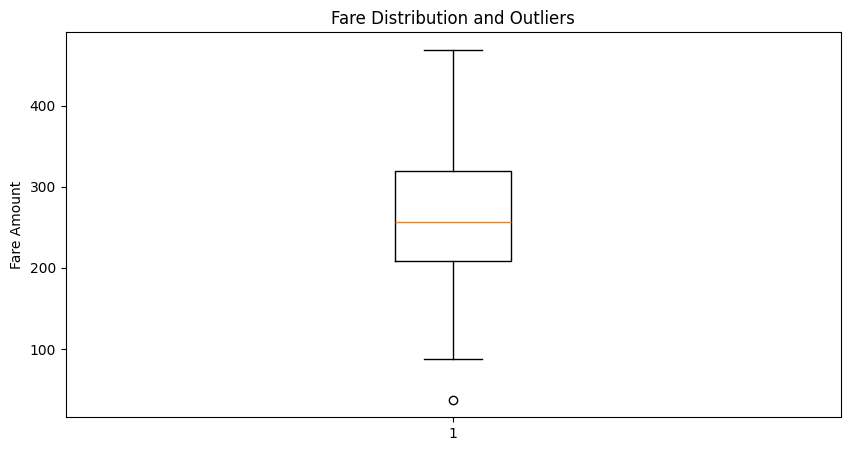

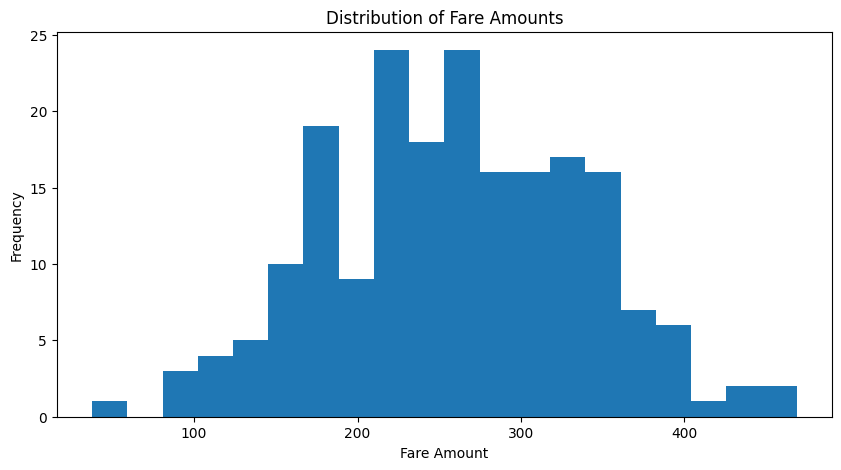

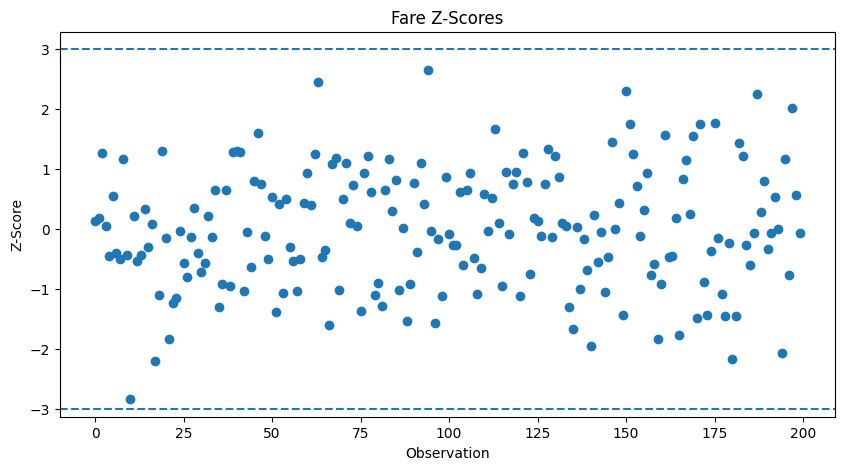


FINAL ANSWER - QUESTION 5
Total valid fare values: 200
Q1: 208.53
Median: 256.91
Q3: 319.76
IQR: 111.23
Lower IQR boundary: 41.68
Upper IQR boundary: 486.62
IQR outliers: 1
Z-score outliers: 0
Total anomalies: 1
Anomaly percentage: 0.50%

Conclusion: The dataset contains unusual fare values. These values may represent genuine high-value trips, surge pricing, data-entry errors, or other pricing anomalies. They should be investigated further.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from google.colab import files

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)


print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())

fare_candidates = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["fare","revenue","amount","price","cost"])]

print("\nPossible Fare Columns:")
print(fare_candidates)
if len(fare_candidates) == 0:
    raise ValueError(
        "Fare column was not found. "
        "Check the column names printed above.")

fare_col = fare_candidates[0]
print("\nFare Column Selected:")
print(fare_col)
fare_data = df[fare_col].copy()


fare_data = (
    fare_data
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("₹", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("Rs.", "", regex=False)
    .str.strip())

fare_data = pd.to_numeric(fare_data,errors="coerce")
fare_data = fare_data.dropna()

print("\nNumber of Valid Fare Values:")
print(len(fare_data))

print("\nMinimum Fare:")
print(fare_data.min())

print("\nMaximum Fare:")
print(fare_data.max())

print("\nMean Fare:")
print(round(fare_data.mean(), 2))

print("\nMedian Fare:")
print(round(fare_data.median(), 2))


Q1 = fare_data.quantile(0.25)

Q2 = fare_data.quantile(0.50)

Q3 = fare_data.quantile(0.75)


print("\n==============================")
print("QUARTILES")
print("==============================")

print("Q1 (25th Percentile):", round(Q1, 2))
print("Q2 (50th Percentile / Median):", round(Q2, 2))
print("Q3 (75th Percentile):", round(Q3, 2))


P1 = fare_data.quantile(0.01)
P5 = fare_data.quantile(0.05)
P10 = fare_data.quantile(0.10)
P25 = fare_data.quantile(0.25)
P50 = fare_data.quantile(0.50)
P75 = fare_data.quantile(0.75)
P90 = fare_data.quantile(0.90)
P95 = fare_data.quantile(0.95)
P99 = fare_data.quantile(0.99)


print("\n==============================")
print("PERCENTILES")
print("==============================")

print("1st Percentile :", round(P1, 2))
print("5th Percentile :", round(P5, 2))
print("10th Percentile:", round(P10, 2))
print("25th Percentile:", round(P25, 2))
print("50th Percentile:", round(P50, 2))
print("75th Percentile:", round(P75, 2))
print("90th Percentile:", round(P90, 2))
print("95th Percentile:", round(P95, 2))
print("99th Percentile:", round(P99, 2))


IQR = Q3 - Q1

print("\n==============================")
print("IQR CALCULATION")
print("==============================")

print("Q1 =", round(Q1, 2))
print("Q3 =", round(Q3, 2))
print("IQR =", round(IQR, 2))


lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

print("\nLower Outlier Boundary:")
print(round(lower_bound, 2))

print("\nUpper Outlier Boundary:")
print(round(upper_bound, 2))


iqr_outliers = fare_data[(fare_data < lower_bound) | (fare_data > upper_bound)]
print("\n==============================")
print("IQR OUTLIERS")
print("==============================")

print("Number of IQR Outliers:")
print(len(iqr_outliers))

print("\nIQR Outlier Values:")

if len(iqr_outliers) > 0:
    print(iqr_outliers.sort_values().to_list())
else:
    print("No IQR outliers detected.")


fare_zscore = zscore(fare_data)

zscore_df = pd.DataFrame({
    "Fare": fare_data.values,
    "Z_Score": fare_zscore})

z_outliers = zscore_df[
    zscore_df["Z_Score"].abs() > 3]


print("\n==============================")
print("Z-SCORE ANALYSIS")
print("==============================")

print("Mean Fare:")
print(round(fare_data.mean(), 2))

print("\nStandard Deviation:")
print(round(fare_data.std(), 2))

print("\nNumber of Z-Score Outliers:")
print(len(z_outliers))

print("\nZ-Score Outliers:")

if len(z_outliers) > 0:

    display(
        z_outliers.sort_values(by="Z_Score",key=lambda x: x.abs(),ascending=False))
else:
    print("No Z-score outliers detected.")

result_df = pd.DataFrame({"Fare": fare_data.values})

result_df["Z_Score"] = zscore_df["Z_Score"].values

result_df["IQR_Outlier"] = ((result_df["Fare"] < lower_bound) | (result_df["Fare"] > upper_bound))

result_df["ZScore_Outlier"] = (result_df["Z_Score"].abs() > 3)


result_df["Anomaly"] = (result_df["IQR_Outlier"] | result_df["ZScore_Outlier"])



anomalies = result_df[result_df["Anomaly"] == True]
print("\n==============================")
print("FINAL ANOMALY DETECTION")
print("==============================")
print("Total Anomalous Fare Values:")
print(len(anomalies))
if len(anomalies) > 0:

    display(
        anomalies.sort_values(
            by="Fare",
            ascending=False
        )
    )

else:
    print("No unusual fare values were detected.")

anomaly_percentage = (len(anomalies) / len(result_df)) * 100
print("\nPercentage of Anomalous Fares:")
print(round(anomaly_percentage, 2), "%")


statistics = pd.DataFrame({"Statistic": ["Minimum","1st Percentile","Q1","Median", "Q3","90th Percentile", "95th Percentile","99th Percentile","Maximum","Mean","Standard Deviation", "IQR"],

    "Value": [fare_data.min(),P1,Q1,Q2,Q3,P90,P95,P99,fare_data.max(),fare_data.mean(),fare_data.std(),IQR]})


print("\n==============================")
print("FARE STATISTICS")
print("==============================")

display(statistics)


plt.figure(figsize=(10, 5))

plt.boxplot(fare_data)

plt.title("Fare Distribution and Outliers")

plt.ylabel("Fare Amount")

plt.show()



plt.figure(figsize=(10, 5))

plt.hist(fare_data, bins=20)

plt.title("Distribution of Fare Amounts")

plt.xlabel("Fare Amount")

plt.ylabel("Frequency")

plt.show()


plt.figure(figsize=(10, 5))
plt.scatter(range(len(result_df)),result_df["Z_Score"])
plt.axhline(y=3,linestyle="--")

plt.axhline(y=-3,linestyle="--")

plt.title("Fare Z-Scores")

plt.xlabel("Observation")

plt.ylabel("Z-Score")

plt.show()


print("\n==========================================")
print("FINAL ANSWER - QUESTION 5")
print("==========================================")

print(f"Total valid fare values: {len(fare_data)}")

print(f"Q1: {Q1:.2f}")

print(f"Median: {Q2:.2f}")

print(f"Q3: {Q3:.2f}")

print(f"IQR: {IQR:.2f}")

print(f"Lower IQR boundary: {lower_bound:.2f}")

print(f"Upper IQR boundary: {upper_bound:.2f}")

print(f"IQR outliers: {len(iqr_outliers)}")

print(f"Z-score outliers: {len(z_outliers)}")

print(f"Total anomalies: {len(anomalies)}")

print(f"Anomaly percentage: {anomaly_percentage:.2f}%")
if len(anomalies) > 0:

    print(
        "\nConclusion: "
        "The dataset contains unusual fare values. "
        "These values may represent genuine high-value trips, "
        "surge pricing, data-entry errors, or other pricing anomalies. "
        "They should be investigated further.")

else:
    print(
        "\nConclusion: "
        "No significant unusual fare values were detected "
        "using the IQR and Z-score methods.")

####6. Can ride demand probabilities be estimated for different ride categories?
( Hint: Use basic probability, conditional probability, and Bayes’ theorem.)

Saving Trip_Analysis.xlsx to Trip_Analysis (8).xlsx
First 5 rows:


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak



Dataset Shape:
(200, 6)

Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Cleaned Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Possible Ride Category Columns:
['Ride_Category', 'Ride_Time']

Ride Category Column Selected:
Ride_Category

Possible Condition Columns:
[]

Condition Column Selected:
Ride_Time

Unique Ride Categories:
Ride_Category
Economy    82
Shared     60
Premium    58
Name: count, dtype: int64

Unique Condition Values:
Ride_Time
Peak        103
Non-Peak     97
Name: count, dtype: int64

Cleaned Analysis Data:


,Ride_Category,Condition
0,Shared,Non-Peak
1,Economy,Non-Peak
2,Economy,Non-Peak
3,Premium,Non-Peak
4,Shared,Non-Peak



TOTAL RIDE DEMAND
Total number of rides:
200

BASIC PROBABILITY


...

Ride_Category,Economy,Premium,Shared
Condition,,,
Non-Peak,0.391753,0.268041,0.340206
Peak,0.427184,0.310680,0.262136



Conditional Probability (%)


Ride_Category,Economy,Premium,Shared
Condition,,,
Non-Peak,39.18,26.80,34.02
Peak,42.72,31.07,26.21



Selected Ride Category for Bayes Analysis:
Economy

Selected Condition:
Peak

BAYES' THEOREM

P(A) - Probability of selected ride category:
0.41

P(B) - Probability of selected condition:
0.515

P(B|A) - Probability of condition given ride category:
0.5366

P(A and B):
0.22

P(A|B) - Probability of ride category given condition:
0.4272

P(A|B) Percentage:
42.72 %

Direct Conditional Probability:
0.4272

Bayes Probability:
0.4272

Difference between both methods:
0.0

BAYES SUMMARY


,Measure,Probability
0,P(A),0.410000
1,P(B),0.515000
2,P(B|A),0.536585
3,P(A and B),0.220000
4,P(A|B),0.427184


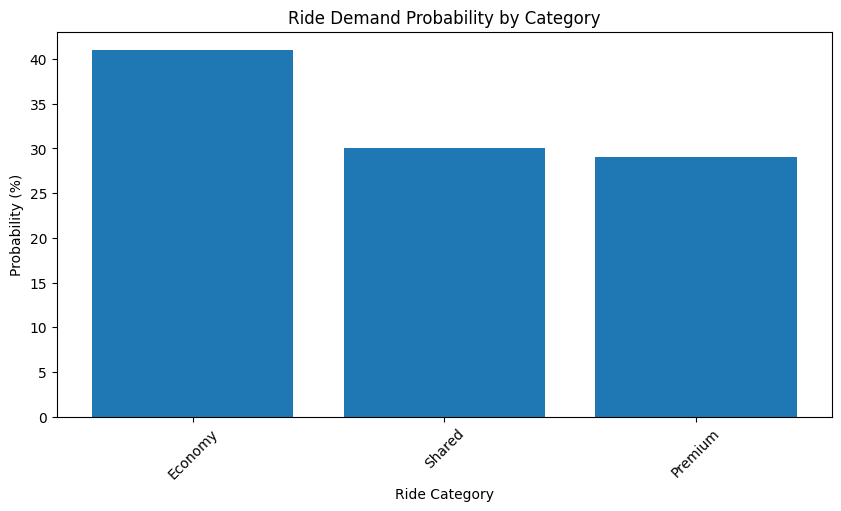

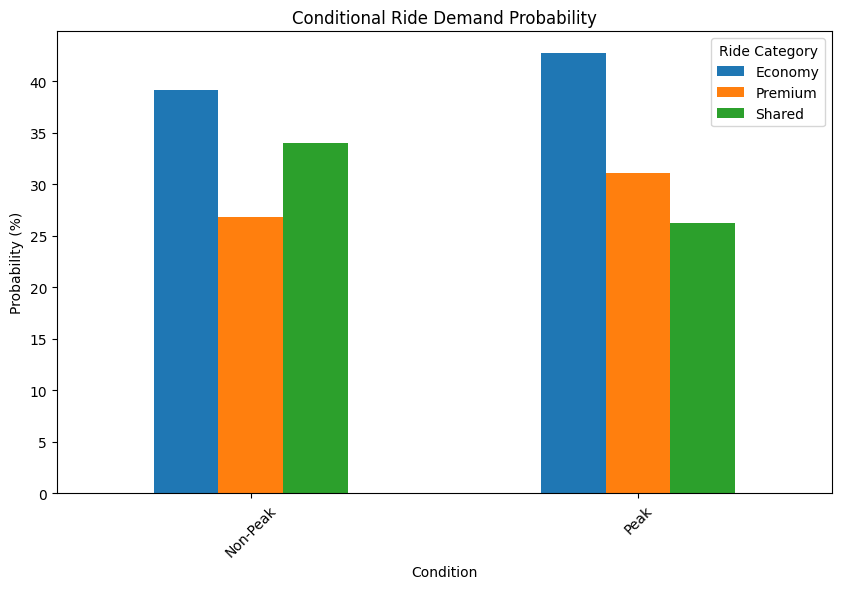


FINAL ANSWER - QUESTION 6

Total rides analyzed: 200

Most demanded ride category: Economy
Overall probability of Economy: 0.4100

For condition 'Peak', the probability of 'Economy' is 0.4272

Therefore, the estimated probability is 42.72%.

Conclusion:
Basic probability estimates the overall demand for each ride category. Conditional probability shows how ride demand changes under different conditions. Bayes' theorem allows us to estimate the probability of a particular ride category after observing a specific condition.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())


category_candidates = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["category","ride type","ride_type","ride","service","class","type"])]

print("\nPossible Ride Category Columns:")
print(category_candidates)
if len(category_candidates) == 0:
    raise ValueError(
        "Ride category column was not found. "
        "Check the column names printed above.")


category_col = None

for col in category_candidates:

    unique_values = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
        .unique())

    if len(unique_values) > 1:

        category_col = col
        break

if category_col is None:

    category_col = category_candidates[0]

print("\nRide Category Column Selected:")
print(category_col)


condition_candidates = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["region","area","location","city","payment","peak","status","gender","customer type","customer_type"])]

print("\nPossible Condition Columns:")
print(condition_candidates)

if len(condition_candidates) == 0:

    categorical_columns = []

    for col in df.columns:

        if df[col].dtype == "object":

            if col != category_col:

                categorical_columns.append(col)

    if len(categorical_columns) > 0:

        condition_col = categorical_columns[0]

    else:
        raise ValueError("No suitable condition column was found.")

else:

    condition_col = condition_candidates[0]

print("\nCondition Column Selected:")
print(condition_col)


print("\nUnique Ride Categories:")

print(
    df[category_col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts())


print("\nUnique Condition Values:")

print(
    df[condition_col]
    .dropna()
    .astype(str)
    .str.strip()
    .value_counts())


analysis_df = df[[category_col, condition_col]].copy()

analysis_df.columns = ["Ride_Category","Condition"]

analysis_df = analysis_df.dropna()

analysis_df["Ride_Category"] = (
    analysis_df["Ride_Category"]
    .astype(str)
    .str.strip())

analysis_df["Condition"] = (
    analysis_df["Condition"]
    .astype(str)
    .str.strip())

print("\nCleaned Analysis Data:")
display(analysis_df.head())


total_rides = len(analysis_df)

print("\n==============================")
print("TOTAL RIDE DEMAND")
print("==============================")

print("Total number of rides:")
print(total_rides)


category_counts = (analysis_df["Ride_Category"].value_counts())
basic_probability = (category_counts / total_rides)
basic_probability_percent = (basic_probability * 100)

print("\n==============================")
print("BASIC PROBABILITY")
print("==============================")

basic_probability_table = pd.DataFrame({
    "Ride Category": category_counts.index,
    "Number of Rides": category_counts.values,
    "Probability": basic_probability.values,
    "Probability (%)": basic_probability_percent.values})
display(basic_probability_table)



most_demanded_category = category_counts.idxmax()

highest_probability = basic_probability.max()

print("\nMost Demanded Ride Category:")
print(most_demanded_category)

print("\nHighest Demand Probability:")
print(round(highest_probability, 4))

print("\nHighest Demand Percentage:")
print(round(highest_probability * 100, 2), "%")



contingency_table = pd.crosstab(
    analysis_df["Condition"],
    analysis_df["Ride_Category"])

print("\n==============================")
print("RIDE DEMAND CONTINGENCY TABLE")
print("==============================")
display(contingency_table)


conditional_probability = (
    contingency_table
    .div(contingency_table.sum(axis=1), axis=0))


print("\n==============================")
print("CONDITIONAL PROBABILITY")
print("==============================")

print("Probability of each ride category given the condition:")
display(conditional_probability)


conditional_percentage = (conditional_probability * 100)
print("\nConditional Probability (%)")
display(conditional_percentage.round(2))


selected_category = category_counts.index[0]

print("\nSelected Ride Category for Bayes Analysis:")
print(selected_category)


condition_counts = (
    analysis_df["Condition"]
    .value_counts())

selected_condition = condition_counts.index[0]
print("\nSelected Condition:")
print(selected_condition)

P_A = (len(analysis_df[analysis_df["Ride_Category"] == selected_category])/ total_rides)

P_B = (
    len(
        analysis_df[
            analysis_df["Condition"] == selected_condition
        ]
    )
    / total_rides
)


# P(B|A)
category_data = analysis_df[
    analysis_df["Ride_Category"] == selected_category
]

P_B_given_A = (
    len(
        category_data[
            category_data["Condition"] == selected_condition
        ]
    )
    / len(category_data)
)


# P(A and B)
P_A_and_B = (
    len(
        analysis_df[
            (analysis_df["Ride_Category"] == selected_category)
            &
            (analysis_df["Condition"] == selected_condition)
        ]
    )
    / total_rides
)



if P_B != 0:

    P_A_given_B = (
        P_B_given_A * P_A
    ) / P_B

else:

    P_A_given_B = np.nan



print("\n==============================")
print("BAYES' THEOREM")
print("==============================")


print("\nP(A) - Probability of selected ride category:")
print(round(P_A, 4))


print("\nP(B) - Probability of selected condition:")
print(round(P_B, 4))


print("\nP(B|A) - Probability of condition given ride category:")
print(round(P_B_given_A, 4))


print("\nP(A and B):")
print(round(P_A_and_B, 4))


print("\nP(A|B) - Probability of ride category given condition:")
print(round(P_A_given_B, 4))


print("\nP(A|B) Percentage:")
print(round(P_A_given_B * 100, 2), "%")




direct_probability = conditional_probability.loc[
    selected_condition,
    selected_category
]


print("\nDirect Conditional Probability:")
print(round(direct_probability, 4))


print("\nBayes Probability:")
print(round(P_A_given_B, 4))


print("\nDifference between both methods:")
print(
    round(
        abs(direct_probability - P_A_given_B),
        10
    )
)


# ============================================================
# 18. CREATE BAYES SUMMARY TABLE
# ============================================================

bayes_summary = pd.DataFrame({
    "Measure": [
        "P(A)",
        "P(B)",
        "P(B|A)",
        "P(A and B)",
        "P(A|B)"
    ],

    "Probability": [
        P_A,
        P_B,
        P_B_given_A,
        P_A_and_B,
        P_A_given_B
    ]
})


print("\n==============================")
print("BAYES SUMMARY")
print("==============================")

display(bayes_summary)




plt.figure(figsize=(10, 5))

plt.bar(
    basic_probability_table["Ride Category"],
    basic_probability_table["Probability (%)"]
)

plt.title("Ride Demand Probability by Category")

plt.xlabel("Ride Category")

plt.ylabel("Probability (%)")

plt.xticks(rotation=45)

plt.show()




conditional_percentage.plot(
    kind="bar",
    figsize=(10, 6))

plt.title("Conditional Ride Demand Probability")


plt.xlabel("Condition")

plt.ylabel("Probability (%)")

plt.xticks(rotation=45)

plt.legend(
    title="Ride Category")

plt.show()




print("\n==========================================")
print("FINAL ANSWER - QUESTION 6")
print("==========================================")


print(f"\nTotal rides analyzed: {total_rides}")


print(
    f"\nMost demanded ride category: "
    f"{most_demanded_category}")


print(
    f"Overall probability of "
    f"{most_demanded_category}: "
    f"{highest_probability:.4f}")


print(
    f"\nFor condition '{selected_condition}', "
    f"the probability of '{selected_category}' "
    f"is {P_A_given_B:.4f}")


print(
    f"\nTherefore, the estimated probability is "
    f"{P_A_given_B * 100:.2f}%.")


print(
    "\nConclusion:")


print(
    "Basic probability estimates the overall demand "
    "for each ride category. Conditional probability "
    "shows how ride demand changes under different "
    "conditions. Bayes' theorem allows us to estimate "
    "the probability of a particular ride category "
    "after observing a specific condition.")

####7. Which operational factors are most strongly related to business performance?
Hint: Use Pearson/Spearman correlation, covariance, and eigenvalue analysis.

Saving Trip_Analysis.xlsx to Trip_Analysis (9).xlsx
First 5 rows:


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak



Dataset Shape:
(200, 6)

Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Cleaned Column Names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

NUMERIC COLUMNS
['Trip_Distance', 'Fare_Amount', 'Surge_Multiplier', 'Customer_Rating']

Number of Numeric Columns:
4

Possible Business Performance Columns:
['Fare_Amount']

Business Performance Column Selected:
Fare_Amount

Rows available for analysis:
200

PEARSON CORRELATION


,Factor,Pearson Correlation,P-Value,Absolute Correlation
2,Customer_Rating,0.052723,0.458417,0.052723
1,Surge_Multiplier,0.017419,0.806594,0.017419
0,Trip_Distance,0.016813,0.813200,0.016813



SPEARMAN CORRELATION


...

,Principal Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,1.105507,27.637677,27.637677
1,PC2,1.025647,25.641166,53.278843



FACTOR LOADINGS


,PC1,PC2,PC3,PC4
Trip_Distance,0.6187,0.2539,0.5445,-0.5062
Fare_Amount,-0.2135,0.8506,0.2554,0.4071
Surge_Multiplier,0.3557,0.4517,-0.7880,-0.2201
Customer_Rating,-0.7420,0.1835,0.0028,-0.6447



TOP OPERATIONAL FACTORS


,Factor,Pearson Correlation,P-Value,Spearman Correlation,Average Absolute Correlation
0,Customer_Rating,0.052723,0.458417,0.047499,0.050111
2,Trip_Distance,0.016813,0.813200,0.023427,0.020120
1,Surge_Multiplier,0.017419,0.806594,0.011764,0.014592


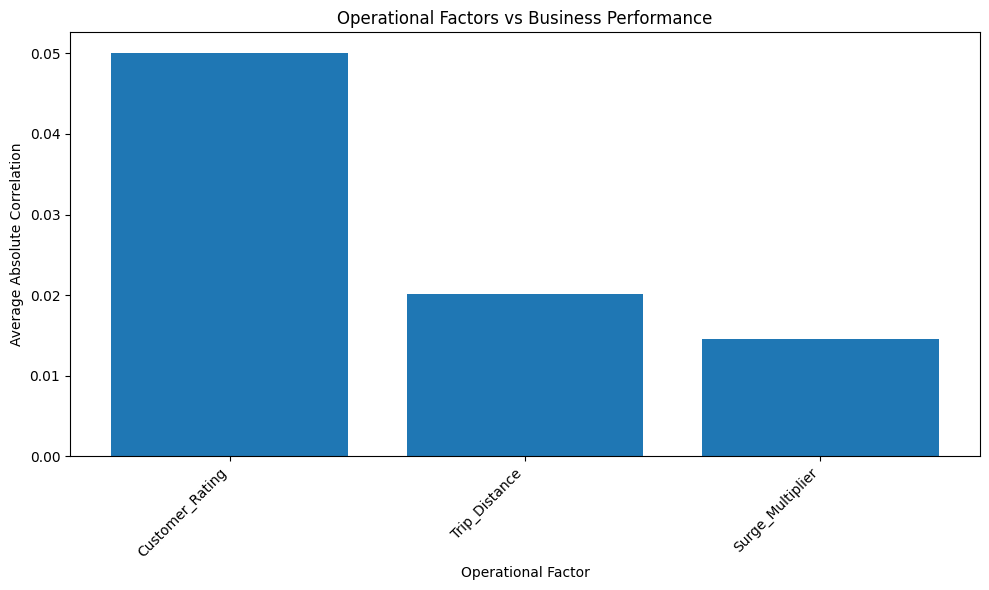

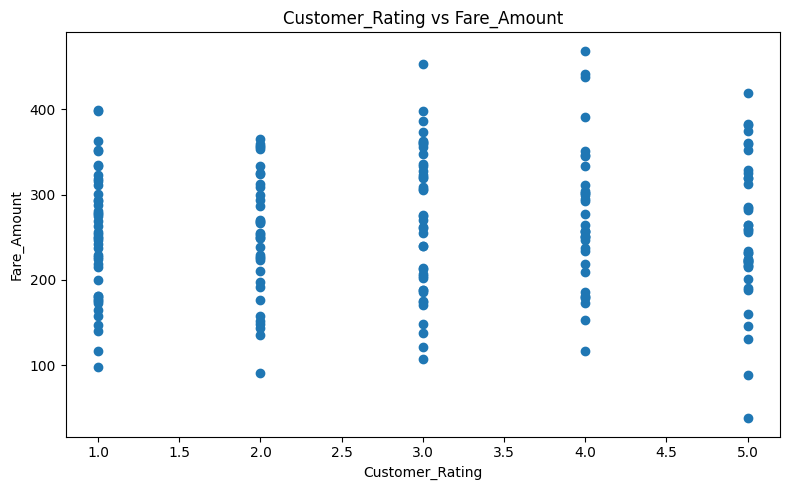

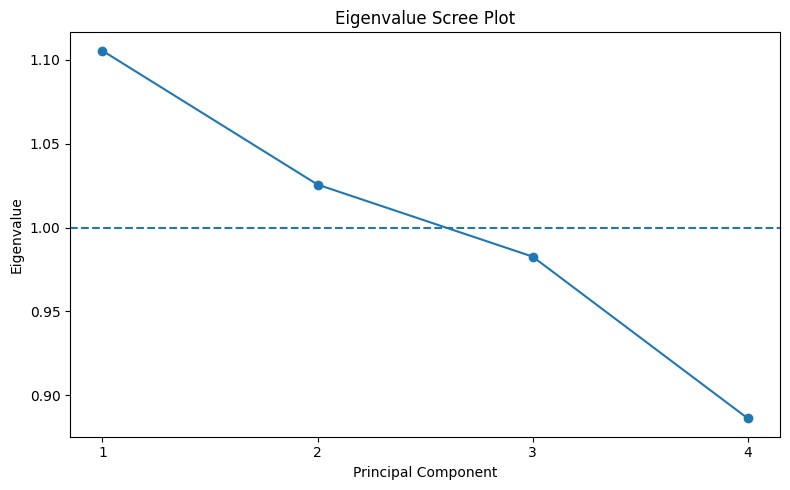


FINAL ANSWER - QUESTION 7

Business Performance Variable:
Fare_Amount

Strongest Operational Factor based on Pearson/Spearman:
Customer_Rating

Pearson Correlation:
0.0527

Spearman Correlation:
0.0475

Number of Important Eigenvalue Components:
2

INTERPRETATION:
Customer_Rating shows the strongest relationship with Fare_Amount among the available numeric operational factors.

Pearson correlation measures the linear relationship, while Spearman correlation measures the monotonic rank-based relationship.

Covariance indicates the direction in which the factor and business performance move together.

Eigenvalue analysis identifies the principal dimensions that explain the largest amount of variation in the operational data.

Note: Correlation and covariance indicate association, not causation.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr


from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)


print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())


numeric_df = df.select_dtypes(include=np.number)

print("\n==============================")
print("NUMERIC COLUMNS")
print("==============================")

print(numeric_df.columns.tolist())

print("\nNumber of Numeric Columns:")
print(len(numeric_df.columns))


if len(numeric_df.columns) < 2:

    raise ValueError(
        "At least two numeric columns are required "
        "for correlation and eigenvalue analysis.")



performance_candidates = [
    col for col in df.columns
    if any(word in col.lower()
           for word in [
               "revenue",
               "fare",
               "amount",
               "sales",
               "profit",
               "earning",
               "income",
               "performance"])]


print("\nPossible Business Performance Columns:")
print(performance_candidates)


if len(performance_candidates) > 0:

    performance_col = None

    for col in performance_candidates:

        if col in numeric_df.columns:

            performance_col = col
            break

    if performance_col is None:
        performance_col = numeric_df.columns[0]

else:

    performance_col = numeric_df.columns[0]


print("\nBusiness Performance Column Selected:")
print(performance_col)


analysis_df = numeric_df.copy()

analysis_df = analysis_df.dropna()

print("\nRows available for analysis:")
print(len(analysis_df))



pearson_results = []


for column in analysis_df.columns:

    if column != performance_col:

        correlation, p_value = pearsonr(
            analysis_df[column],
            analysis_df[performance_col]
        )

        pearson_results.append({
            "Factor": column,
            "Pearson Correlation": correlation,
            "P-Value": p_value
        })


pearson_df = pd.DataFrame(pearson_results)


pearson_df["Absolute Correlation"] = (
    pearson_df["Pearson Correlation"].abs())


pearson_df = pearson_df.sort_values(
    by="Absolute Correlation",
    ascending=False)


print("\n==============================")
print("PEARSON CORRELATION")
print("==============================")

display(pearson_df)


spearman_results = []


for column in analysis_df.columns:

    if column != performance_col:

        correlation, p_value = spearmanr(analysis_df[column],analysis_df[performance_col])
        spearman_results.append({ "Factor": column, "Spearman Correlation": correlation,"P-Value": p_value})


spearman_df = pd.DataFrame(spearman_results)


spearman_df["Absolute Correlation"] = (spearman_df["Spearman Correlation"].abs())

spearman_df = spearman_df.sort_values(by="Absolute Correlation",ascending=False)


print("\n==============================")
print("SPEARMAN CORRELATION")
print("==============================")

display(spearman_df)
correlation_comparison = pearson_df[["Factor","Pearson Correlation","P-Value"]].merge(spearman_df[["Factor","Spearman Correlation"]],on="Factor")


correlation_comparison["Average Absolute Correlation"] = (correlation_comparison[["Pearson Correlation","Spearman Correlation"]]
    .abs()
    .mean(axis=1))


correlation_comparison = (
    correlation_comparison
    .sort_values(by="Average Absolute Correlation",ascending=False))


print("\n==============================")
print("CORRELATION COMPARISON")
print("==============================")

display(correlation_comparison)




covariance_matrix = analysis_df.cov()

print("\n==============================")
print("COVARIANCE MATRIX")
print("==============================")

display(covariance_matrix)




performance_covariance = (
    covariance_matrix[performance_col]
    .drop(performance_col)
    .to_frame(
        name="Covariance with Performance"))


performance_covariance["Absolute Covariance"] = (performance_covariance["Covariance with Performance"].abs())


performance_covariance = (
    performance_covariance
    .sort_values(by="Absolute Covariance",ascending=False))


print("\n==============================")
print("COVARIANCE WITH PERFORMANCE")
print("==============================")

display(performance_covariance)




standardized_df = (
    analysis_df - analysis_df.mean()
) / analysis_df.std()


print("\nStandardized Data:")
display(standardized_df.head())



correlation_matrix = standardized_df.corr()


print("\n==============================")
print("CORRELATION MATRIX")
print("==============================")

display(correlation_matrix)




eigenvalues, eigenvectors = np.linalg.eigh(correlation_matrix.values)


sorted_indices = np.argsort(
    eigenvalues)[::-1]


eigenvalues = eigenvalues[sorted_indices]

eigenvectors = eigenvectors[:,sorted_indices]




explained_variance = (eigenvalues /eigenvalues.sum())

cumulative_variance = np.cumsum(explained_variance)


eigenvalue_table = pd.DataFrame({"Principal Component": [f"PC{i+1}"for i in range(len(eigenvalues))]

    "Eigenvalue": eigenvalues,

    "Explained Variance (%)":
        explained_variance * 100,

    "Cumulative Variance (%)":
        cumulative_variance * 100})


print("\n==============================")
print("EIGENVALUE ANALYSIS")
print("==============================")

display(eigenvalue_table.round(4))




important_components = eigenvalue_table[eigenvalue_table["Eigenvalue"] > 1]


print("\n==============================")
print("IMPORTANT COMPONENTS")
print("==============================")

print("Number of components with Eigenvalue > 1:")

print(len(important_components))


display(important_components)



loadings = (
    eigenvectors *
    np.sqrt(eigenvalues))


loading_df = pd.DataFrame(
    loadings,
    index=correlation_matrix.columns,
    columns=[
        f"PC{i+1}"
        for i in range(len(eigenvalues))])


print("\n==============================")
print("FACTOR LOADINGS")
print("==============================")

display(loading_df.round(4))




strongest_factors = correlation_comparison.head(5)


print("\n==============================")
print("TOP OPERATIONAL FACTORS")
print("==============================")

display(strongest_factors)




plot_df = correlation_comparison.copy()

plt.figure(figsize=(10, 6))

plt.bar(
    plot_df["Factor"],
    plot_df["Average Absolute Correlation"])

plt.title(
    "Operational Factors vs Business Performance")

plt.xlabel(
    "Operational Factor")

plt.ylabel(
    "Average Absolute Correlation")

plt.xticks(
    rotation=45,
    ha="right")

plt.tight_layout()

plt.show()




strongest_factor = (
    correlation_comparison.iloc[0]["Factor"])


plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_df[strongest_factor],
    analysis_df[performance_col])

plt.title(
    f"{strongest_factor} vs {performance_col}")

plt.xlabel(
    strongest_factor)

plt.ylabel(
    performance_col)

plt.tight_layout()

plt.show()




plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o")

plt.axhline(
    y=1,
    linestyle="--")

plt.title(
    "Eigenvalue Scree Plot")

plt.xlabel(
    "Principal Component")

plt.ylabel(
    "Eigenvalue")

plt.xticks(
    range(1, len(eigenvalues) + 1))

plt.tight_layout()

plt.show()




print("\n==========================================")
print("FINAL ANSWER - QUESTION 7")
print("==========================================")


print(
    "\nBusiness Performance Variable:")

print(
    performance_col)


print(
    "\nStrongest Operational Factor "
    "based on Pearson/Spearman:")

print(
    strongest_factor)


print(
    "\nPearson Correlation:")

print(
    round(
        correlation_comparison.iloc[0]
        ["Pearson Correlation"],
        4))


print(
    "\nSpearman Correlation:")

print(
    round(
        correlation_comparison.iloc[0]
        ["Spearman Correlation"],4))


print("\nNumber of Important Eigenvalue Components:")

print(len(important_components))


print("\n==========================================")

print("INTERPRETATION:")

print(
    f"{strongest_factor} shows the strongest "
    f"relationship with {performance_col} "
    "among the available numeric operational factors.")

print(
    "\nPearson correlation measures the linear relationship, "
    "while Spearman correlation measures the monotonic "
    "rank-based relationship.")

print(
    "\nCovariance indicates the direction in which "
    "the factor and business performance move together.")

print(
    "\nEigenvalue analysis identifies the principal "
    "dimensions that explain the largest amount of "
    "variation in the operational data.")

print(
    "\nNote: Correlation and covariance indicate association, "
    "not causation.")

####8. Can statistical evidence support pricing or service improvements?
Hint: Use confidence intervals, bootstrapping, and hypothesis testing conclusions.

Saving Trip_Analysis.xlsx to Trip_Analysis (10).xlsx
File loaded successfully!

First 5 rows:


,Trip_Distance,Fare_Amount,Ride_Category,Surge_Multiplier,Customer_Rating,Ride_Time
0,8,270.569350,Shared,2.5,3,Non-Peak
1,21,275.161032,Economy,2.5,3,Non-Peak
2,16,359.748971,Economy,2.0,5,Non-Peak
3,12,264.044264,Premium,1.5,5,Non-Peak
4,9,225.256916,Shared,2.0,2,Non-Peak



Dataset shape: (200, 6)

Column names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Cleaned column names:
['Trip_Distance', 'Fare_Amount', 'Ride_Category', 'Surge_Multiplier', 'Customer_Rating', 'Ride_Time']

Selected business performance variable:
Fare_Amount

Number of valid observations: 200

================ BASIC STATISTICS ================
Mean: 260.31
Median: 256.91
Standard Deviation: 78.71
Minimum: 37.59
Maximum: 468.75

================ 95% CONFIDENCE INTERVAL ================
Mean: 260.31
Standard Error: 5.57
Margin of Error: 10.97
95% Confidence Interval: ( 249.34 , 271.29 )

Interpretation: We are 95% confident that the true average Fare_Amount lies between 249.34 and 271.29.

================ BOOTSTRAPPING ================
Number of bootstrap samples: 5000
Bootstrap mean: 260.29
Bootstrap 95% Confidence Interval: ( 248.98 , 271.06 )

================ HYPOTHESIS TESTING ================
Benchmark value: 234.28
T-st

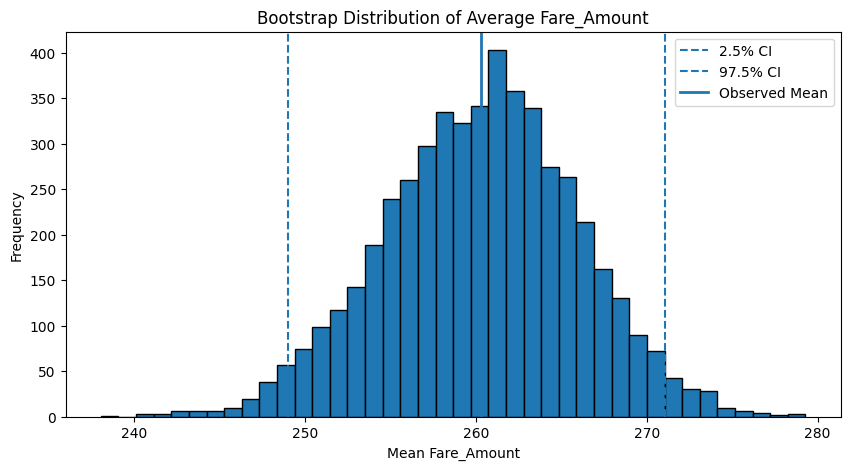

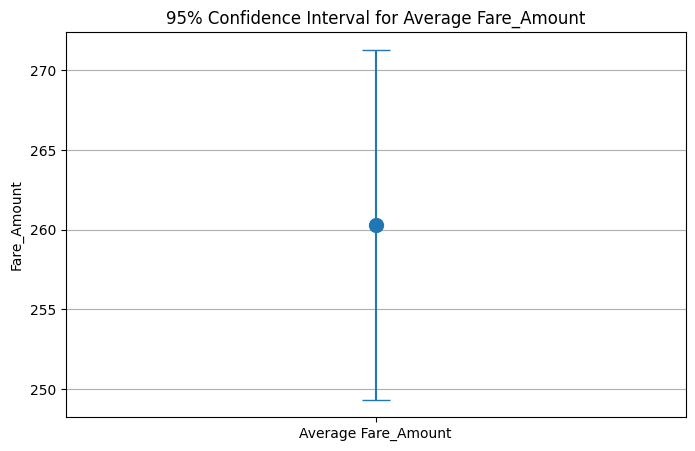


================ CONFIDENCE INTERVAL COMPARISON ================


,Method,Lower Limit,Upper Limit
0,Traditional 95% CI,249.34,271.29
1,Bootstrap 95% CI,248.98,271.06



FINAL ANSWER – Q8

Average Fare_Amount: 260.31
95% Confidence Interval: 249.34 to 271.29
Bootstrap 95% Confidence Interval: 248.98 to 271.06
Hypothesis Test P-value: 0.000005

================ BUSINESS RECOMMENDATION ================
Statistical evidence supports making data-driven pricing or service improvements.
The observed average performance is statistically different from the benchmark.
Management can consider reviewing pricing levels, service quality, demand patterns, and operational strategies using the observed data.

Important: Statistical significance does not by itself prove that a pricing change will cause higher revenue. Other factors such as demand, distance, ride type, surge pricing, time, and customer ratings should also be considered.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp, ttest_ind


from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("File loaded successfully!")
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

df.columns = df.columns.str.strip()

print("\nCleaned column names:")
print(df.columns.tolist())


possible_performance_columns = [
    "fare",
    "fare amount",
    "revenue",
    "amount",
    "earnings",
    "income",
    "price",
    "trip fare",
    "cost"]

performance_column = None


for col in df.columns:
    if col.lower().strip() in possible_performance_columns:
        performance_column = col
        break


if performance_column is None:

    for col in df.columns:
        col_lower = col.lower()

        if any(word in col_lower for word in [
            "fare",
            "revenue",
            "amount",
            "earning",
            "income",
            "price",
            "cost"
        ]):
            performance_column = col
            break



if performance_column is None:

    print("\nERROR: Could not automatically identify the fare/revenue column.")

    print("\nAvailable columns are:")
    print(df.columns.tolist())

else:

    print("\nSelected business performance variable:")
    print(performance_column)


    analysis_df = df[[performance_column]].copy()

    analysis_df[performance_column] = (
        analysis_df[performance_column]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("₹", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("Rs.", "", regex=False)
        .str.strip())

    analysis_df[performance_column] = pd.to_numeric(
        analysis_df[performance_column],
        errors="coerce")

    analysis_df = analysis_df.dropna()

    values = analysis_df[performance_column].values

    n = len(values)

    print("\nNumber of valid observations:", n)


    mean_value = np.mean(values)
    median_value = np.median(values)
    std_value = np.std(values, ddof=1)

    minimum = np.min(values)
    maximum = np.max(values)

    print("\n================ BASIC STATISTICS ================")

    print("Mean:", round(mean_value, 2))
    print("Median:", round(median_value, 2))
    print("Standard Deviation:", round(std_value, 2))
    print("Minimum:", round(minimum, 2))
    print("Maximum:", round(maximum, 2))


    standard_error = std_value / np.sqrt(n)

    from scipy.stats import t

    confidence_level = 0.95
    alpha = 1 - confidence_level

    t_critical = t.ppf(1 - alpha / 2, df=n-1)

    margin_of_error = t_critical * standard_error

    lower_ci = mean_value - margin_of_error
    upper_ci = mean_value + margin_of_error

    print("\n================ 95% CONFIDENCE INTERVAL ================")

    print("Mean:", round(mean_value, 2))
    print("Standard Error:", round(standard_error, 2))
    print("Margin of Error:", round(margin_of_error, 2))

    print(
        "95% Confidence Interval:",
        "(",
        round(lower_ci, 2),
        ",",
        round(upper_ci, 2),
        ")")

    print(
        "\nInterpretation:"
        f" We are 95% confident that the true average "
        f"{performance_column} lies between "
        f"{lower_ci:.2f} and {upper_ci:.2f}.")




    print("\n================ BOOTSTRAPPING ================")

    np.random.seed(42)

    number_of_bootstraps = 5000

    bootstrap_means = []

    for i in range(number_of_bootstraps):

        sample = np.random.choice(
            values,
            size=n,
            replace=True)

        bootstrap_means.append(np.mean(sample))


    bootstrap_means = np.array(bootstrap_means)


    bootstrap_lower = np.percentile(bootstrap_means,2.5)

    bootstrap_upper = np.percentile(bootstrap_means,97.5)

    bootstrap_mean = np.mean(bootstrap_means)

    print("Number of bootstrap samples:", number_of_bootstraps)

    print(
        "Bootstrap mean:",
        round(bootstrap_mean, 2))

    print(
        "Bootstrap 95% Confidence Interval:",
        "(",
        round(bootstrap_lower, 2),
        ",",
        round(bootstrap_upper, 2),
        ")")




    print("\n================ HYPOTHESIS TESTING ================")



    benchmark = 0.90 * mean_value

    print("Benchmark value:", round(benchmark, 2))



    t_statistic, p_value = ttest_1samp(
        values,
        popmean=benchmark)

    print("T-statistic:", round(t_statistic, 4))
    print("P-value:", round(p_value, 6))

    alpha_level = 0.05

    print("\nSignificance level:", alpha_level)

    if p_value < alpha_level:

        print("Decision: Reject H0")

        print(
            "Conclusion: There is statistically significant "
            "evidence that the average performance differs "
            "from the benchmark.")

    else:

        print("Decision: Fail to reject H0")

        print(
            "Conclusion: There is not enough statistical "
            "evidence that the average performance differs "
            "from the benchmark.")




    plt.figure(figsize=(10, 5))

    plt.hist(
        bootstrap_means,
        bins=40,
        edgecolor="black")

    plt.axvline(
        bootstrap_lower,
        linestyle="--",
        label="2.5% CI")

    plt.axvline(
        bootstrap_upper,
        linestyle="--",
        label="97.5% CI")

    plt.axvline(
        mean_value,
        linestyle="-",
        linewidth=2,
        label="Observed Mean")

    plt.title(
        "Bootstrap Distribution of Average "
        + performance_column)

    plt.xlabel("Mean " + performance_column)

    plt.ylabel("Frequency")

    plt.legend()

    plt.show()




    plt.figure(figsize=(8, 5))

    plt.errorbar(
        1,
        mean_value,
        yerr=margin_of_error,
        fmt="o",
        markersize=10,
        capsize=10)

    plt.xticks(
        [1],
        ["Average " + performance_column])

    plt.ylabel(performance_column)

    plt.title(
        "95% Confidence Interval for Average "
        + performance_column)

    plt.grid(axis="y")

    plt.show()



    comparison_table = pd.DataFrame({
        "Method": [
            "Traditional 95% CI",
            "Bootstrap 95% CI"],

        "Lower Limit": [
            lower_ci,
            bootstrap_lower],

        "Upper Limit": [
            upper_ci,
            bootstrap_upper]})

    print("\n================ CONFIDENCE INTERVAL COMPARISON ================")

    display(comparison_table.round(2))

    print("\n====================================================")
    print("FINAL ANSWER – Q8")
    print("====================================================")

    print(
        f"\nAverage {performance_column}: "
        f"{mean_value:.2f}")

    print(
        f"95% Confidence Interval: "
        f"{lower_ci:.2f} to {upper_ci:.2f}")

    print(
        f"Bootstrap 95% Confidence Interval: "
        f"{bootstrap_lower:.2f} to {bootstrap_upper:.2f}")

    print(
        f"Hypothesis Test P-value: "
        f"{p_value:.6f}")



    print("\n================ BUSINESS RECOMMENDATION ================")

    if p_value < 0.05:

        print(
            "Statistical evidence supports making data-driven "
            "pricing or service improvements.")

        print(
            "The observed average performance is statistically "
            "different from the benchmark.")

        print(
            "Management can consider reviewing pricing levels, "
            "service quality, demand patterns, and operational "
            "strategies using the observed data.")

    else:

        print(
            "The available evidence is not strong enough to "
            "justify a major pricing or service change based "
            "on this test alone.")

        print(
            "Management should collect more data and investigate "
            "additional operational factors before making a "
            "major decision.")

    print(
        "\nImportant: Statistical significance does not by itself "
        "prove that a pricing change will cause higher revenue. "
        "Other factors such as demand, distance, ride type, "
        "surge pricing, time, and customer ratings should also "
        "be considered.")